# K-Means Clustering using Mall Customers Dataset

**Author:** Varun Singh

**GitHub:** https://github.com/varunsingh-dev

**Repository:** Machine Learning

**Module:** 07_K_Means_Clustering

**Dataset:** Mall_Customers.csv

**Objective:** Segment customers into different groups based on their annual income and spending score using K-Means Clustering.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


##  Statistical Summary

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Check Missing Values

In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


##  Check Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

##  Select Features for Clustering

In [11]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##  Selected Features

In [12]:
print("Features used for clustering:")
print(X.columns.tolist())

print("\nDataset Shape:", X.shape)

Features used for clustering:
['Annual Income (k$)', 'Spending Score (1-100)']

Dataset Shape: (200, 2)


## Visualize Customer Income vs Spending Score

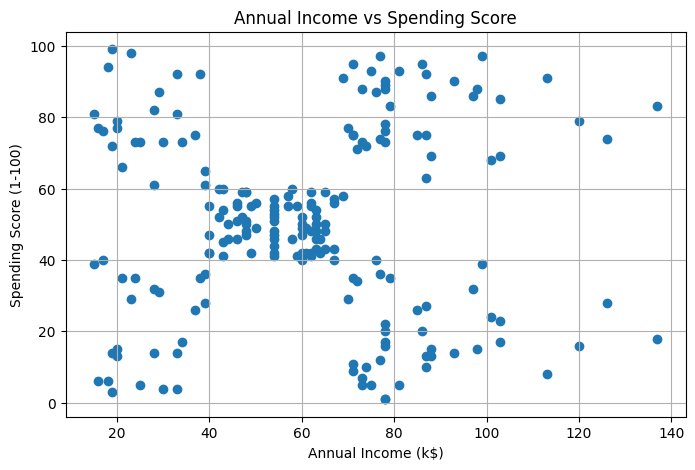

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.grid(True)
plt.show()

##  Import K-Means

In [14]:
from sklearn.cluster import KMeans

##  Elbow Method

The Elbow Method helps determine the optimal number of clusters by calculating the WCSS for different values of K.

In [15]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28000000014, 181363.59595959607, 106348.37306211119, 73679.78903948837, 44448.45544793369, 37233.81451071002, 30241.34361793659, 25036.417604033977, 21916.79478984372, 20072.070939404]


## Elbow Curve

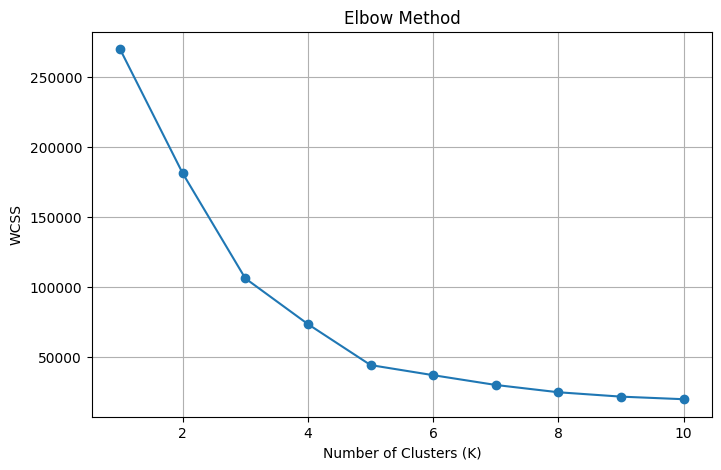

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()

##  Optimal Number of Clusters

Based on the Elbow Method, we select K = 5.

In [17]:
optimal_k = 5

print("Optimal Number of Clusters:", optimal_k)

Optimal Number of Clusters: 5


##  Train K-Means Model

In [18]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=42)

##  Assign Customer Clusters

In [19]:
df["Cluster"] = kmeans.labels_

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [20]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')

##  Customers in Each Cluster

In [21]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


##  Customer Clusters Visualization

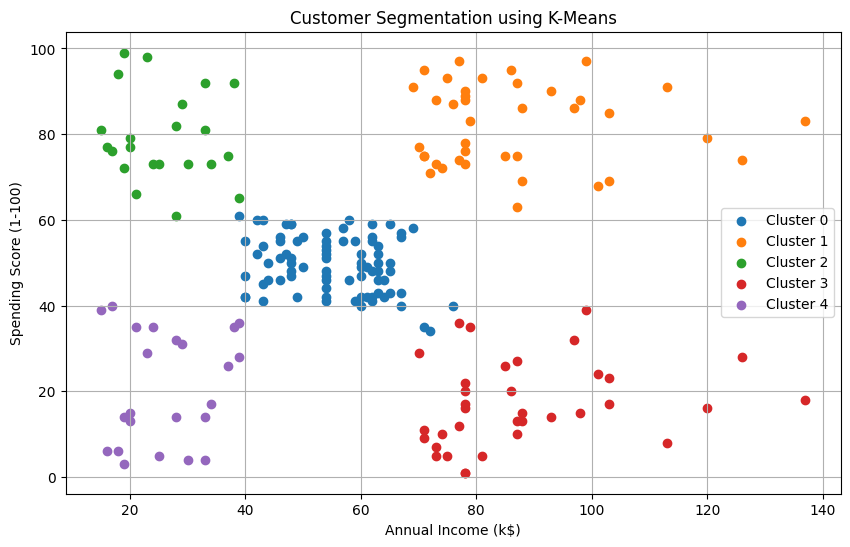

In [22]:
plt.figure(figsize=(10, 6))

for cluster in range(optimal_k):
    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

##  Cluster Centroids

In [23]:
centroids = kmeans.cluster_centers_

print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


## Visualize Centroids

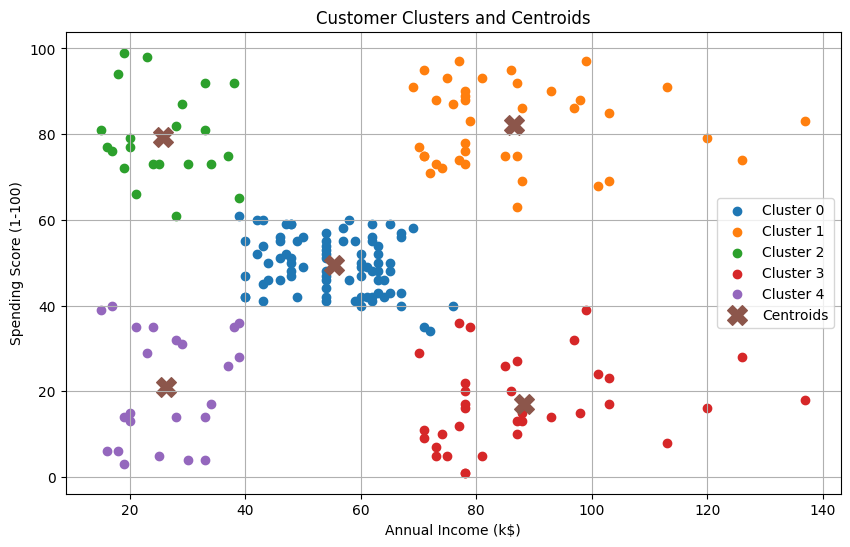

In [24]:
plt.figure(figsize=(10, 6))

for cluster in range(optimal_k):
    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("Customer Clusters and Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

##  Cluster Summary

In [25]:
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [26]:
cluster_summary["Customer Count"] = df["Cluster"].value_counts().sort_index()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,
0,55.296296,49.518519,81
1,86.538462,82.128205,39
2,25.727273,79.363636,22
3,88.200000,17.114286,35
4,26.304348,20.913043,23


##  High-Spending Customers

In [27]:
high_spending = df[
    df["Spending Score (1-100)"] >= 70
]

high_spending.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
1,2,Male,21,15,81,2
3,4,Female,23,16,77,2
5,6,Female,22,17,76,2
7,8,Female,23,18,94,2
9,10,Female,30,19,72,2


##  Customer Segment Interpretation

The K-Means algorithm divided the customers into five different clusters.

### Cluster Analysis

- **Low Income / Low Spending:** Customers with lower income and lower spending behavior.
- **Low Income / High Spending:** Customers with lower income but relatively high spending behavior.
- **Average Income / Average Spending:** Customers with moderate income and spending.
- **High Income / Low Spending:** Customers with high income but relatively low spending.
- **High Income / High Spending:** High-value customers with high income and high spending.

These segments can help businesses create targeted marketing strategies.

##  Business Insights

K-Means customer segmentation can help businesses:

- Identify high-value customers.
- Target high-income and high-spending customers with premium offers.
- Create personalized marketing campaigns.
- Develop strategies for low-spending customers.
- Understand different customer groups.
- Improve customer retention and engagement.

Customer segmentation allows businesses to make data-driven marketing decisions.

##  Final Dataset with Cluster Labels

In [31]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


#  Key Learnings

- Learned the concept of Unsupervised Machine Learning.
- Loaded and explored the Mall Customers dataset.
- Selected relevant features for clustering.
- Used the Elbow Method to determine the optimal number of clusters.
- Implemented K-Means Clustering.
- Assigned customers to different clusters.
- Visualized customer segments and cluster centroids.
- Analyzed cluster characteristics.
- Derived business insights from customer segmentation.

##  Project Summary

In this project, K-Means Clustering was used to segment mall customers based on their annual income and spending score.

The Elbow Method was used to select the appropriate number of clusters. The resulting customer segments provide useful insights that can support targeted marketing and customer management strategies.